In [17]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC




In [18]:
warnings.filterwarnings('ignore')
df = pd.read_csv("processed/data_merge_p2.csv", index_col=0)

In [19]:


X_rh = df.drop('a_quitte_l_entreprise', axis=1)
y_rh = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_rh, y_rh, test_size=0.2, random_state=42)

In [20]:
colonnes_categorielles = ['frequence_deplacement', 
                          'domaine_etude', 
                          'poste', 
                          'departement', 
                          'statut_marital']

preprocessor = ColumnTransformer(
    transformers=[
        # Nom du transformateur, Classe, colonnes à transformer
        ('onehot', OneHotEncoder(handle_unknown='ignore'), colonnes_categorielles)
        # Les autres colonnes (numériques) seront gérées par 'remainder'
    ],
    remainder='passthrough' # 'passthrough' = Laisse les autres colonnes (numériques) intactes
)
print("--- Forme (shape) de X_train original ---")
print(X_train.shape)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


--- Forme (shape) de X_train original ---
(1176, 30)


In [21]:


print("\n--- Forme de X_train après OneHotEncoding ---")
print(X_train.shape)

print("\n--- Forme de X_test après OneHotEncoding ---")
print(X_test.shape)


--- Forme de X_train après OneHotEncoding ---
(1176, 49)

--- Forme de X_test après OneHotEncoding ---
(294, 49)


In [22]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import MinMaxScaler


def modele_classification(df, target_col, modele_type, use_smote=False, scaler_type='none', n_splits=5):
    # Séparer les features et la cible
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    colonnes_categorielles = ['frequence_deplacement', 
                            'domaine_etude', 
                            'poste', 
                            'departement', 
                            'statut_marital']
    
    colonnes_numeriques = X.select_dtypes(include=np.number).columns

    # Logique pour choisir le scaler en fonction du paramètre
    if scaler_type == 'standard':
        numeric_transformer = StandardScaler()
    elif scaler_type == 'minmax':
        numeric_transformer = MinMaxScaler()
    elif scaler_type == 'none':
        numeric_transformer = 'passthrough' # 'passthrough' est l'option "ne rien faire"
    else:
        raise ValueError("Type de scaler non reconnu. Choisissez 'standard', 'minmax', or 'none'.")

    preprocessor = ColumnTransformer(
        transformers=[
            # Nom du transformateur, Classe, colonnes à transformer
            ('onehot', OneHotEncoder(handle_unknown='ignore'), colonnes_categorielles),
            # Étape 2 : Appliquer le scaler choisi aux colonnes numériques
            ('scaler', numeric_transformer, colonnes_numeriques)
        ],
        remainder='passthrough' # 'passthrough' = Laisse les autres colonnes (numériques) intactes
    )



    # Choisir le modèle
    if modele_type == 'logisticregression':
        model = LogisticRegression(max_iter=5000, class_weight="balanced" if not use_smote else None)
    elif modele_type == 'dummyclassifier':
        model = DummyClassifier(strategy='most_frequent')
    elif modele_type == 'svc':
        model = SVC(probability=True, class_weight='balanced' if not use_smote else None)
    elif modele_type == 'randomforestclassifier':
        model = RandomForestClassifier(random_state=42, class_weight="balanced" if not use_smote else None)
    elif modele_type == 'xgboost':
        scale_pos_weight = (y == 0).sum() / (y == 1).sum() if not use_smote else 1
        model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
    else:
        raise ValueError("Type de modèle non reconnu. Choisissez parmi : 'logisticregression', 'dummyclassifier', 'svc', 'randomforestclassifier', 'xgboost'.")
    
    #Construire la Pipeline
    steps = []
    steps.append(('preprocessor', preprocessor))

    if use_smote:
        smote = SMOTE(sampling_strategy='minority', random_state=42)
        steps.append(('smote', smote))

    steps.append(('model', model))

    pipeline = ImbPipeline(steps=steps)


    # Cross validate
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    print(f"===== ÉVALUATION (CV={n_splits} folds) POUR : {modele_type} (SMOTE={use_smote}, Scaler={scaler_type}) =====")
    scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    
    try:
        results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        
        print("\n--- Scores de Validation Croisée (moyenne) ---")
        print(f"Accuracy:  {np.mean(results['test_accuracy']):.4f} +- {np.std(results['test_accuracy']):.4f}")
        print(f"Precision: {np.mean(results['test_precision_macro']):.4f} +- {np.std(results['test_precision_macro']):.4f}")
        print(f"Recall:    {np.mean(results['test_recall_macro']):.4f} +- {np.std(results['test_recall_macro']):.4f}")
        print(f"F1-Score:  {np.mean(results['test_f1_macro']):.4f} +- {np.std(results['test_f1_macro']):.4f}")

    
    except Exception as e:
        print(f"Erreur pendant cross_validate : {e}")

    try:
        y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv, n_jobs=-1)
        
        print("\n--- Rapport de Classification (basé sur cross_val_predict) ---")
        report = classification_report(y, y_pred_cv)
        print(report)
        
        cm = confusion_matrix(y, y_pred_cv)
        
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    cbar=False, annot_kws={"size": 14})
        plt.title(f'Matrice de Confusion CV - {modele_type}')
        plt.ylabel('Vraie valeur (Actual)')
        plt.xlabel('Prédiction (Predicted)')
        plt.show()
        
        print("=" * (50 + len(modele_type)))
        
        return results, y_pred_cv
        
    except Exception as e:
        print(f"Erreur pendant cross_val_predict : {e}")
        return None, None
    

===== ÉVALUATION (CV=5 folds) POUR : dummyclassifier (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8388 +- 0.0017
Precision: 0.4194 +- 0.0008
Recall:    0.5000 +- 0.0000
F1-Score:  0.4562 +- 0.0005

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1233
           1       0.00      0.00      0.00       237

    accuracy                           0.84      1470
   macro avg       0.42      0.50      0.46      1470
weighted avg       0.70      0.84      0.77      1470



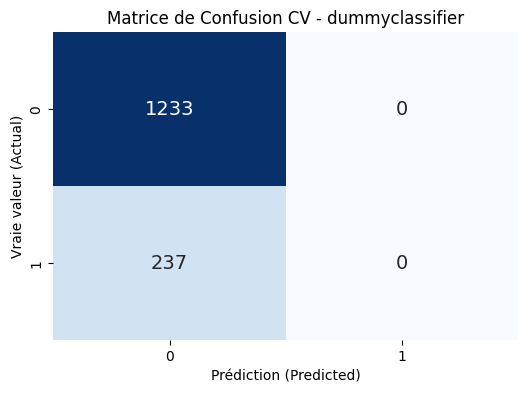

In [23]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'dummyclassifier')

===== ÉVALUATION (CV=5 folds) POUR : randomforestclassifier (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8551 +- 0.0035
Precision: 0.8375 +- 0.0520
Recall:    0.5658 +- 0.0178
F1-Score:  0.5766 +- 0.0275

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1233
           1       0.79      0.14      0.24       237

    accuracy                           0.86      1470
   macro avg       0.82      0.57      0.58      1470
weighted avg       0.85      0.86      0.81      1470



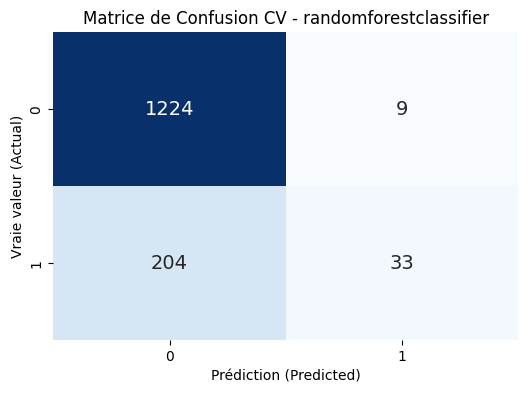

In [24]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'randomforestclassifier')

===== ÉVALUATION (CV=5 folds) POUR : logisticregression (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.7544 +- 0.0180
Precision: 0.6512 +- 0.0082
Recall:    0.7411 +- 0.0129
F1-Score:  0.6626 +- 0.0128

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.93      0.76      0.84      1233
           1       0.37      0.72      0.49       237

    accuracy                           0.75      1470
   macro avg       0.65      0.74      0.66      1470
weighted avg       0.84      0.75      0.78      1470



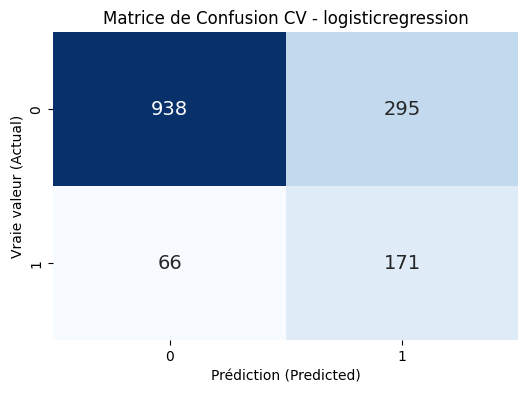

In [25]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'logisticregression')

===== ÉVALUATION (CV=5 folds) POUR : svc (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.6673 +- 0.0079
Precision: 0.5727 +- 0.0120
Recall:    0.6225 +- 0.0228
F1-Score:  0.5629 +- 0.0104

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      1233
           1       0.26      0.56      0.35       237

    accuracy                           0.67      1470
   macro avg       0.57      0.62      0.56      1470
weighted avg       0.79      0.67      0.71      1470



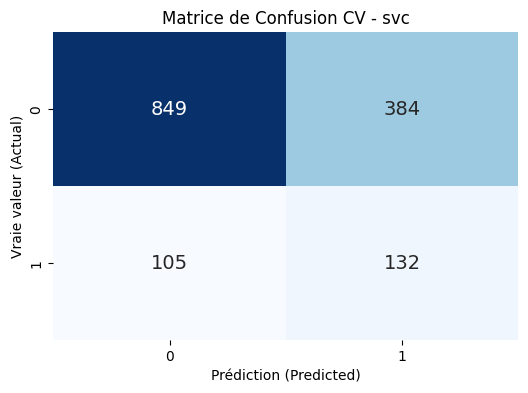

In [26]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'svc')

===== ÉVALUATION (CV=5 folds) POUR : xgboost (SMOTE=True, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8707 +- 0.0131
Precision: 0.7827 +- 0.0386
Recall:    0.6777 +- 0.0254
F1-Score:  0.7100 +- 0.0284

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      1233
           1       0.67      0.39      0.49       237

    accuracy                           0.87      1470
   macro avg       0.78      0.68      0.71      1470
weighted avg       0.86      0.87      0.86      1470



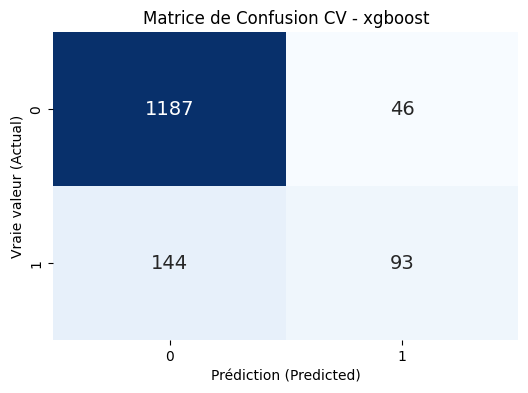

In [27]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost', True)

===== ÉVALUATION (CV=5 folds) POUR : xgboost (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8592 +- 0.0199
Precision: 0.7452 +- 0.0506
Recall:    0.6743 +- 0.0327
F1-Score:  0.6989 +- 0.0384

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1233
           1       0.59      0.40      0.48       237

    accuracy                           0.86      1470
   macro avg       0.74      0.67      0.70      1470
weighted avg       0.84      0.86      0.85      1470



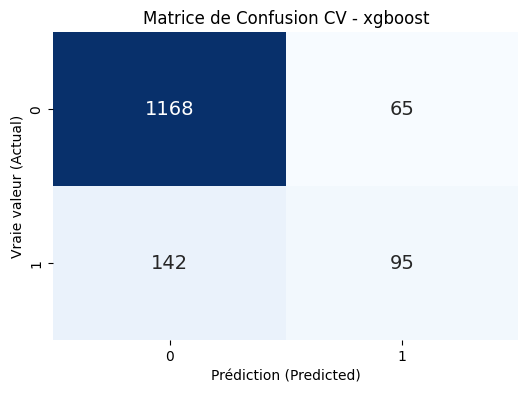

In [28]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost', False)

### XGBoost avec ou sans SMOTE ne change pas significativement les resultats testons en mettant ou non un scaler


===== ÉVALUATION (CV=5 folds) POUR : xgboost (SMOTE=False, Scaler=none) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8592 +- 0.0199
Precision: 0.7452 +- 0.0506
Recall:    0.6743 +- 0.0327
F1-Score:  0.6989 +- 0.0384

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1233
           1       0.59      0.40      0.48       237

    accuracy                           0.86      1470
   macro avg       0.74      0.67      0.70      1470
weighted avg       0.84      0.86      0.85      1470



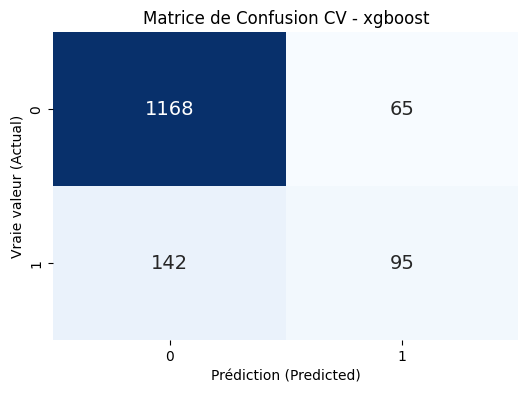

In [29]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost', False, scaler_type="none")

===== ÉVALUATION (CV=5 folds) POUR : xgboost (SMOTE=True, Scaler=standard) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8714 +- 0.0167
Precision: 0.7835 +- 0.0508
Recall:    0.6779 +- 0.0327
F1-Score:  0.7108 +- 0.0392

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      1233
           1       0.67      0.39      0.50       237

    accuracy                           0.87      1470
   macro avg       0.78      0.68      0.71      1470
weighted avg       0.86      0.87      0.86      1470



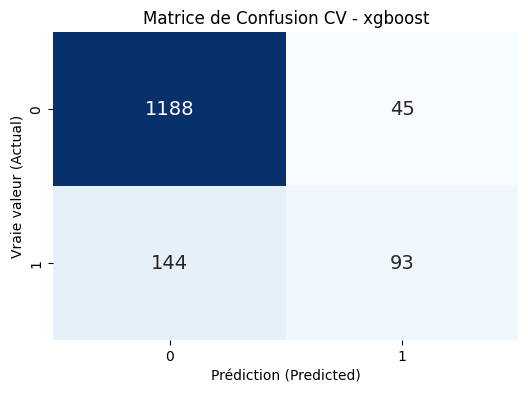

In [30]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost', True, scaler_type="standard")

===== ÉVALUATION (CV=5 folds) POUR : xgboost (SMOTE=True, Scaler=minmax) =====

--- Scores de Validation Croisée (moyenne) ---
Accuracy:  0.8667 +- 0.0177
Precision: 0.7674 +- 0.0492
Recall:    0.6768 +- 0.0340
F1-Score:  0.7061 +- 0.0385

--- Rapport de Classification (basé sur cross_val_predict) ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1233
           1       0.64      0.40      0.49       237

    accuracy                           0.87      1470
   macro avg       0.77      0.68      0.71      1470
weighted avg       0.85      0.87      0.85      1470



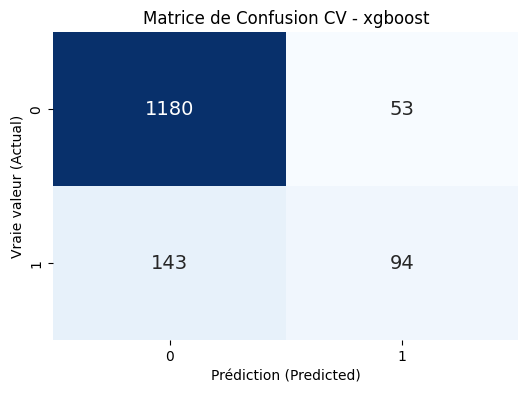

In [31]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'xgboost', True, scaler_type="minmax")

## Le scaler n'as pas d'impact significatif je n'en utiliserais donc pas pour l'optimisation, idem pour SMOTE